In [1]:
import pycaret

In [2]:
import pandas as pd
import numpy as np

In [9]:
# Load dataset

df = pd.read_csv('/content/Bank_Loan_Granting.csv')

In [4]:
# Preprocessing

df["CCAvg"] = df["CCAvg"].str.replace('/', '.')
df["CCAvg"] = df["CCAvg"].astype(float)

In [5]:
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [6]:
# Remove first column

df = df.iloc[:, 1:]

In [7]:
# Check target distribution

print(df["Personal Loan"].value_counts())

Personal Loan
0    4520
1     480
Name: count, dtype: int64


In [8]:
# Percentage distribution

print(df["Personal Loan"].value_counts(normalize=True) * 100)

Personal Loan
0    90.4
1     9.6
Name: proportion, dtype: float64


In [10]:
from pycaret.classification import *

In [11]:
#Setup

model = setup(
    data=df,
    target='Personal Loan',
    session_id=34
)

,Description,Value
0,Session id,34
1,Target,Personal Loan
2,Target type,Binary
3,Original data shape,"(5000, 14)"
4,Transformed data shape,"(5000, 14)"
5,Transformed train set shape,"(3500, 14)"
6,Transformed test set shape,"(1500, 14)"
7,Numeric features,12
8,Categorical features,1
9,Preprocess,True


In [12]:
# Compare models

best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9866,0.9951,0.8988,0.9596,0.9275,0.9201,0.9211,0.1520
lightgbm,Light Gradient Boosting Machine,0.9854,0.9963,0.8810,0.9648,0.9199,0.9119,0.9137,0.3100
rf,Random Forest Classifier,0.9851,0.9966,0.8571,0.9857,0.9161,0.9080,0.9112,0.3260
gbc,Gradient Boosting Classifier,0.9846,0.9955,0.8929,0.9435,0.9169,0.9084,0.9092,0.6260
et,Extra Trees Classifier,0.9809,0.9968,0.8072,0.9929,0.8880,0.8778,0.8848,0.2420
dt,Decision Tree Classifier,0.9800,0.9412,0.8930,0.9001,0.8953,0.8843,0.8850,0.0510
ada,Ada Boost Classifier,0.9663,0.9764,0.7707,0.8668,0.8144,0.7959,0.7985,0.1860
lr,Logistic Regression,0.9549,0.9615,0.6605,0.8381,0.7361,0.7119,0.7194,0.9500
lda,Linear Discriminant Analysis,0.9460,0.9661,0.6637,0.7469,0.7019,0.6724,0.6743,0.0490
ridge,Ridge Classifier,0.9420,0.9677,0.4316,0.9231,0.5870,0.5604,0.6080,0.0810


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [13]:
# Create Extreme Gradient Boosting

xg_boost = create_model('xgboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9971,0.9990,0.9697,1.0000,0.9846,0.9830,0.9832
1,0.9886,0.9935,0.9091,0.9677,0.9375,0.9312,0.9318
2,0.9914,0.9992,0.9394,0.9688,0.9538,0.9491,0.9493
3,0.9743,0.9921,0.7879,0.9286,0.8525,0.8385,0.8419
4,0.9857,0.9893,0.8824,0.9677,0.9231,0.9152,0.9164
5,0.9857,0.9978,0.8824,0.9677,0.9231,0.9152,0.9164
6,0.9886,0.9969,0.8824,1.0000,0.9375,0.9312,0.9334
7,0.9771,0.9924,0.8529,0.9062,0.8788,0.8662,0.8667
8,0.9943,0.9976,0.9412,1.0000,0.9697,0.9665,0.9671


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [15]:
# Tune Extreme Gradient Boosting
tuned_xgboost = tune_model(xg_boost)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9943,1.0000,1.0000,0.9429,0.9706,0.9674,0.9679
1,0.9829,0.9953,0.9091,0.9091,0.9091,0.8996,0.8996
2,0.9829,0.9976,0.9091,0.9091,0.9091,0.8996,0.8996
3,0.9686,0.9835,0.7879,0.8667,0.8254,0.8082,0.8093
4,0.9829,0.9771,0.9118,0.9118,0.9118,0.9023,0.9023
5,0.9800,0.9965,0.9118,0.8857,0.8986,0.8875,0.8876
6,0.9800,0.9953,0.8824,0.9091,0.8955,0.8845,0.8846
7,0.9771,0.9953,0.9118,0.8611,0.8857,0.8730,0.8735
8,0.9971,0.9966,0.9706,1.0000,0.9851,0.9835,0.9836


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [16]:
# Evaluate model
evaluate_model(tuned_xgboost)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [17]:
# Predictions
predictions = predict_model(tuned_xgboost)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.9827,0.9904,0.8472,0.9683,0.9037,0.8942,0.8966


In [18]:
# Display predictions
print(predictions.head())

        ID  Age  Experience  Income  ZIP Code  Family CCAvg  Education  \
2844  2845   60          34      64     95014       3  2/20          3   
2160  2161   43          17      55     93933       3  2/20          2   
1706  1707   56          31      84     92672       1  0/10          3   
1876  1877   62          38     123     90210       1  2/90          1   
1866  1867   48          24      90     94523       1  2/60          2   

      Mortgage  Securities Account  CD Account  Online  CreditCard  \
2844         0                   0           0       0           0   
2160         0                   0           0       0           0   
1706         0                   0           0       1           0   
1876         0                   0           0       0           0   
1866       334                   0           0       1           0   

      Personal Loan  prediction_label  prediction_score  
2844              0                 0            0.9999  
2160              

In [20]:
# Classification report
from sklearn.metrics import classification_report


print(classification_report(
    predictions['Personal Loan'],
    predictions['prediction_label']
))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1356
           1       0.97      0.85      0.90       144

    accuracy                           0.98      1500
   macro avg       0.98      0.92      0.95      1500
weighted avg       0.98      0.98      0.98      1500



In [21]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

print(confusion_matrix(
    predictions['Personal Loan'],
    predictions['prediction_label']
))

[[1352    4]
 [  22  122]]


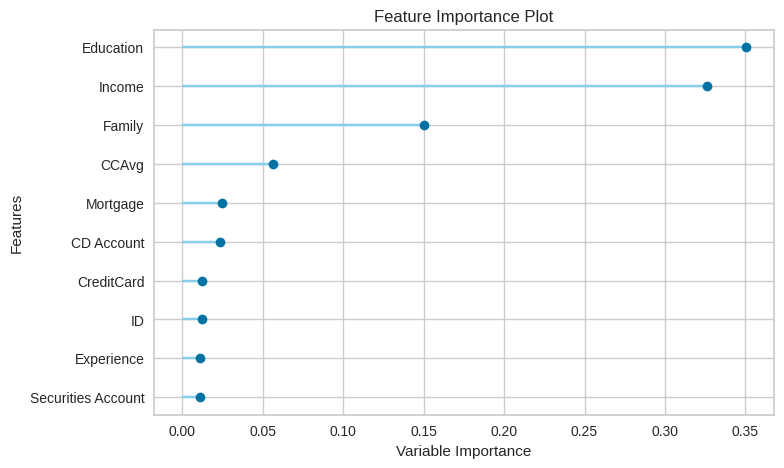

In [23]:
# Feature importance
plot_model(tuned_xgboost, plot='feature')

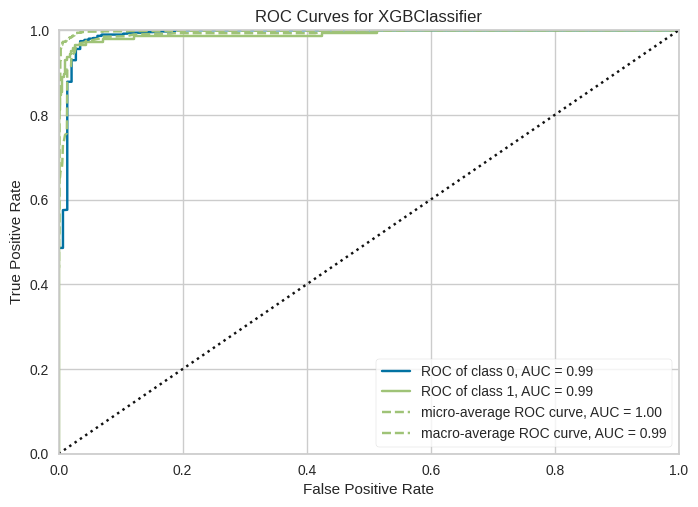

In [25]:
# ROC-AUC
plot_model(tuned_xgboost, plot='auc')


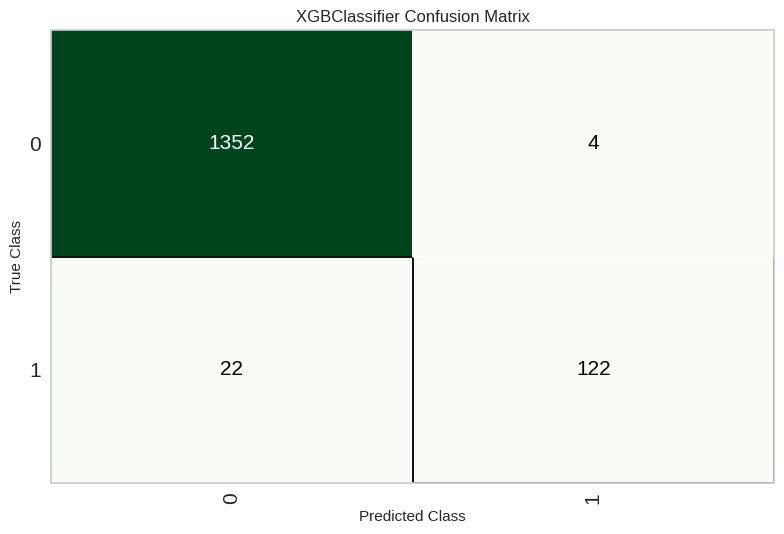

In [26]:
# Confusion matrix visualization
plot_model(tuned_xgboost, plot='confusion_matrix')